# Oxford 102 flowers - Image classification

- uses the train, val, test split from setId.mat
- as trains dataset is small - does offline augmentation
- define custom flowers CNN model - run 40 train epochs
- define resnet18 model - runs 10 epoch

### import libraries

In [1]:
import torch
import numpy as np
import random
import os
from torch import nn

from download_dataset import download_dataset
from offline_augmentation_generator import generate_augmented_dataset
from compute_class_balanced_copies import compute_class_balanced_copies
from hashing import canonicalize_copies_per_class
from CustomFlowerCNN import CustomFlowerCNN

print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

if not torch.cuda.is_available():
  torch.set_num_threads(max(1, os.cpu_count()-1))
  torch.set_num_interop_threads(2)

CUDA available: False


### Download oxford 102 flowers dataset

In [2]:
download_dataset()

Oxford 102 Flowers dataset is ready.


### Run OFFLINE Augmentation

In [3]:
copies_per_class = compute_class_balanced_copies(
    "oxford_102_flowers/imagelabels.mat"
)

copies_per_class = canonicalize_copies_per_class(copies_per_class)

RAW_DIR = "oxford_102_flowers/jpg"
OUTPUT_ROOT = "oxford_102_flowers"

gen_hash = generate_augmented_dataset(
    raw_images_dir=RAW_DIR,
    output_root=OUTPUT_ROOT,
    copies_per_class=copies_per_class
)

print("Generation hash:", gen_hash)
with open(os.path.join(OUTPUT_ROOT, "generation_hash.txt"), "w") as f:
    f.write(gen_hash)

Augmented dataset already exists
Version: v_e2d41bcb6de3
Manifest: oxford_102_flowers\augmented\v_e2d41bcb6de3\dataset.json
Skipping regeneration
Existing dataset is up-to-date with current policy and raw data. No regeneration needed.
Generation hash: e2d41bcb6de3


### Define transforms

##### Device-aware transform choice
When running on CPU we use the offline (deterministic) transform `transform_flowers_train_offline_aug` to avoid expensive per-batch random augmentations that add significant CPU overhead. On systems with a GPU available we use the full `transform_flowers_train` (online augmentation) since the training throughput is higher and the augment cost is better amortized.

This keeps CPU-only runs responsive and reduces noisy benchmarking variance.

In [4]:
from transform_train import transform_flowers_train, transform_flowers_train_offline_aug
from transform_prod import transform_flowers_prod

# Select transform based on device: use offline/no-random-augment transform on CPU to avoid heavy CPU augment costs
selected_train_transform = transform_flowers_train if torch.cuda.is_available() else transform_flowers_train_offline_aug

### Create Datasets

In [5]:
from oxford_flowers_dataset import OxfordFlowersDataset

# RAW TRAIN (used for mixing)
raw_train_ds = OxfordFlowersDataset(
    root_dir="oxford_102_flowers",
    split="train",
    raw_transform=selected_train_transform,
    aug_transform=None,
    use_offline_aug=False,
    prescan=True,
    track_coverage=False,
)

# RAW VAL (clean, no aug, no mixing)
raw_val_ds = OxfordFlowersDataset(
    root_dir="oxford_102_flowers",
    split="val",
    raw_transform=transform_flowers_prod,
    aug_transform=None,
    use_offline_aug=False,
    prescan=True,
    track_coverage=False,
)

print(f"Train images dir: {raw_train_ds.images_dir}")
print(f"Val images dir:   {raw_val_ds.images_dir}")

# Offline augmented TRAIN dataset
aug_train_ds = OxfordFlowersDataset(
    root_dir="oxford_102_flowers",
    split="train",
    raw_transform=transform_flowers_prod,
    aug_transform=None,
    use_offline_aug=True,
    prescan=False,
    track_coverage=False,
)
print(f"Augmented train images dir: {aug_train_ds.images_dir}")

Train images dir: oxford_102_flowers\jpg
Val images dir:   oxford_102_flowers\jpg
Augmented train images dir: oxford_102_flowers\augmented\v_e2d41bcb6de3\train\images


### Mixed raw + augmented sampling

In [6]:
from oxford_flowers_dataset import MixedFlowersDataset

train_ds = MixedFlowersDataset(
    raw_dataset=raw_train_ds,
    aug_dataset=aug_train_ds,
    aug_ratio=0.6
)


### Data Loaders

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

# Use the validation subset created by make_split_subsets
val_loader = DataLoader(
    raw_val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

### Training setup  

In [8]:
def build_model(name, num_classes=102):
    if not name in ["resnet18", "custom"]:
       raise ValueError(f"Unknown model: {name}")
     
    model = None

    if name == "resnet18":
        import torchvision.models as models
        model = models.resnet18(weights="IMAGENET1K_V1")
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, num_classes)
        )        

    elif name == "custom":
        model = CustomFlowerCNN(num_classes)
        
    if not torch.cuda.is_available():
      try:
        model.to(memory_format=torch.channels_last)
      except Exception:
        pass

    return model

        


### Training loop

In [9]:
import time

torch.backends.cudnn.benchmark = True

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        start_time = time.time()
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        print(f"Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f} - Batch time: {time.time() - start_time:.3f}s", end='\r')

    return total_loss / total, correct / total


### Validation

In [10]:
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


### Define train model function

In [12]:
def train_model(model_name):
  print(f"\n=== Training {model_name} ===")

  model = build_model(model_name).to(device)

  optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3 if model_name == "custom" else 3e-4,
        weight_decay=1e-4
    )
  criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40 if model_name == "custom" else 10) 

  history = []

  for epoch in range(40 if model_name == "custom" else 10):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step()
  
    history.append((train_acc, val_acc))

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1} | LR: {current_lr:.6f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    print(
        f"Epoch [{epoch+1}/{40 if model_name == 'custom' else 10}] "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
    )

  return model, history, val_acc


### Train Custom Flowers Model

In [13]:
results = {}

customModel, customHistory, custom_val_acc = train_model("custom")
results["custom"] = customHistory

resnetModel, resnetHistory, resnet_val_acc = train_model("resnet18")
results["resnet18"] = resnetHistory



=== Training custom ===
Epoch 1 | LR: 0.000998 | Train: 0.0842 | Val: 0.1118
Epoch [1/40] Train Loss: 4.1631 Acc: 0.0842 | Val Loss: 3.9358 Acc: 0.1118
Epoch 2 | LR: 0.000994 | Train: 0.1563 | Val: 0.1657
Epoch [2/40] Train Loss: 3.6900 Acc: 0.1563 | Val Loss: 3.7293 Acc: 0.1657
Epoch 3 | LR: 0.000986 | Train: 0.2097 | Val: 0.1863
Epoch [3/40] Train Loss: 3.5040 Acc: 0.2097 | Val Loss: 3.6680 Acc: 0.1863
Epoch 4 | LR: 0.000976 | Train: 0.2422 | Val: 0.1990
Epoch [4/40] Train Loss: 3.3472 Acc: 0.2422 | Val Loss: 3.7332 Acc: 0.1990
Epoch 5 | LR: 0.000962 | Train: 0.2853 | Val: 0.2284
Epoch [5/40] Train Loss: 3.2308 Acc: 0.2853 | Val Loss: 3.6699 Acc: 0.2284
Epoch 6 | LR: 0.000946 | Train: 0.3084 | Val: 0.2441
Epoch [6/40] Train Loss: 3.1443 Acc: 0.3084 | Val Loss: 3.5764 Acc: 0.2441
Epoch 7 | LR: 0.000926 | Train: 0.3143 | Val: 0.2657
Epoch [7/40] Train Loss: 3.0844 Acc: 0.3143 | Val Loss: 3.5843 Acc: 0.2657
Epoch 8 | LR: 0.000905 | Train: 0.3473 | Val: 0.3039
Epoch [8/40] Train Loss: 2

### prepare test dataset

In [14]:
from oxford_flowers_dataset import OxfordFlowersDataset
from transform_prod import transform_flowers_prod

# Create a test dataset using the dedicated 'test' split so the proper test transform is applied
test_ds = OxfordFlowersDataset(
    root_dir="oxford_102_flowers",
    raw_transform=transform_flowers_prod,
    aug_transform=None,   # NO online augmentation
    prescan=True,
    track_coverage=False,  # Optional: no need to track aug coverage for test
    split="test",
)


### Data loader for test

In [15]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,  # always False for evaluation
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

### Evaluate Model

In [16]:
@torch.no_grad()
def test(model, loader):
    model.eval()
    correct, total = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    print(f"✅ Test Accuracy: {acc:.4%}")
    return acc

# custom model - run test
custom_test_acc = test(customModel, test_loader)

print(custom_test_acc)

# resnet model - run test
resnet_test_acc = test(resnetModel, test_loader)

print(resnet_test_acc)


✅ Test Accuracy: 38.5429%
0.3854285249634087
✅ Test Accuracy: 88.4697%
0.8846966986501871


### Per class accuracy

In [17]:
@torch.no_grad()
def test_per_class(model, loader, num_classes=102):
    model.eval()
    correct = [0] * num_classes
    total = [0] * num_classes

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)

        for l, p in zip(labels, preds):
            total[l] += 1
            if l == p:
                correct[l] += 1

    accs = [(c / t if t > 0 else 0) for c, t in zip(correct, total)]
    return accs

In [18]:
# custom model - test per class
custom_class_accs = test_per_class(customModel, test_loader)
print("Custom model - Worst classes:", sorted(custom_class_accs)[:5])
print("Custom model - Best classes:", sorted(custom_class_accs)[-5:])

# resnet model - test per class
resnet_class_accs = test_per_class(resnetModel, test_loader)
print("Resnet model - Worst classes:", sorted(resnet_class_accs)[:5])
print("Resnet model - Best classes:", sorted(resnet_class_accs)[-5:])

Custom model - Worst classes: [0.01818181818181818, 0.028169014084507043, 0.03225806451612903, 0.03529411764705882, 0.047619047619047616]
Custom model - Best classes: [0.9361702127659575, 0.9550561797752809, 0.9666666666666667, 1.0, 1.0]
Resnet model - Worst classes: [0.4789915966386555, 0.5, 0.5277777777777778, 0.6622516556291391, 0.6712328767123288]
Resnet model - Best classes: [1.0, 1.0, 1.0, 1.0, 1.0]


### confusion matrix

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_confusion(model, loader, model_name):
    y_true, y_pred = [], []

    model.eval()
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

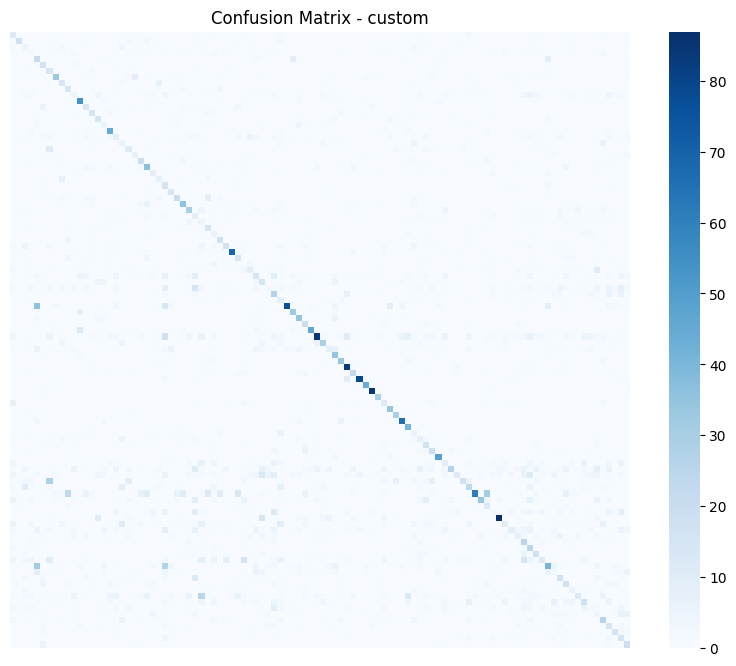

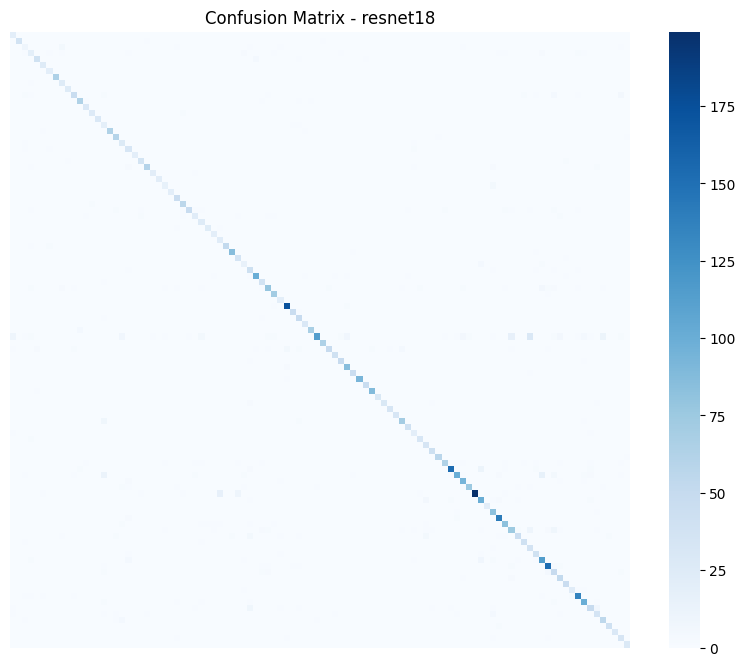

In [20]:
plot_confusion(customModel, test_loader, "custom")
plot_confusion(resnetModel, test_loader, "resnet18")

### Save model and metadata

In [21]:
torch.save({
    "model_state": customModel.state_dict(),
    "architecture": "CustomModel",
    "num_classes": 102,
    "val_acc": custom_val_acc,
    "policy_hash": gen_hash,
    "dataset_version": aug_train_ds.augmentation_version,
}, "flowers_custom_model_v1.pt")

torch.save({
    "model_state": resnetModel.state_dict(),
    "architecture": "resnet18",
    "num_classes": 102,
    "val_acc": custom_val_acc,
    "policy_hash": gen_hash,
    "dataset_version": aug_train_ds.augmentation_version,
}, "flowers_resnet_18_v1.pt")

### Inference Demo

In [23]:
from PIL import Image

def predict_image(model, model_name, path):
    model.eval()
    img = Image.open(path).convert("RGB")
    x = transform_flowers_prod(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)
        cls = probs.argmax(1).item()
        conf = probs.max().item()

    print(f"{model_name} - Predicted class: {cls}, confidence: {conf:.2%}")


predict_image(customModel, "custom", './real-world-images/pink-primrose.jpg')
predict_image(customModel, "custom", './real-world-images/rose.jpg')

predict_image(resnetModel, "resnet18", './real-world-images/pink-primrose.jpg')
predict_image(resnetModel, "resnet18", './real-world-images/rose.jpg')

custom - Predicted class: 86, confidence: 19.85%
custom - Predicted class: 79, confidence: 19.88%
resnet18 - Predicted class: 0, confidence: 23.96%
resnet18 - Predicted class: 73, confidence: 22.03%


### Export for Deployment

In [24]:
example = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(customModel, example, "custom_flowers.onnx")
torch.onnx.export(resnetModel, example, "resnet18_flowers.onnx")

W0212 21:32:11.008000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0212 21:32:11.008000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0212 21:32:11.008000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0212 21:32:11.008000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]',

[torch.onnx] Obtain model graph for `CustomFlowerCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CustomFlowerCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 24 of general pattern rewrite rules.


W0212 21:32:13.426000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0212 21:32:13.426000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0212 21:32:13.426000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0212 21:32:13.426000 20500 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]',

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 40 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.9.1+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[1,3,224,224]>
            ),
            outputs=(
                %"linear"<FLOAT,[1,102]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[64,3,7,7]>{Tensor(...)},
                %"layer1.0.conv1.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.0.conv2.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.1.conv1.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.1.conv2.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer2.0.conv1.weight"<FLOAT,[128,64,3,3]>{Tensor(...)},
                %"layer2.0.conv2.weight"<FLOAT,[128,128,3,3]>{Tensor(...)},
                %"l

In [25]:
import onnxruntime as ort

custom_session = ort.InferenceSession("custom_flowers.onnx")
print([i.name for i in custom_session.get_inputs()])
print([o.name for o in custom_session.get_outputs()])

resnet_custom_session = ort.InferenceSession("resnet18_flowers.onnx")
print([i.name for i in resnet_custom_session.get_inputs()])
print([o.name for o in resnet_custom_session.get_outputs()])


['x']
['linear']
['x']
['linear']


In [26]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

In [27]:
import onnxruntime as ort
import numpy as np
from PIL import Image
from torchvision import transforms


def run_onnx_model(model):
    # ----------------------------
    # CONFIG
    # ----------------------------
    ONNX_MODEL_PATH = model
    IMAGE_PATHS = [
        "./real-world-images/rose.jpg",
        "./real-world-images/pink-primrose.jpg"
    ]

    CLASS_NAMES = None  # optional: list of 102 flower names

    # ----------------------------
    # PREPROCESS (must match training!)
    # ----------------------------
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # ----------------------------
    # LOAD MODEL
    # ----------------------------
    session = ort.InferenceSession(
        ONNX_MODEL_PATH,
        providers=["CPUExecutionProvider"]
    )

    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    # ----------------------------
    # INFERENCE
    # ----------------------------
    for img_path in IMAGE_PATHS:
        img = Image.open(img_path).convert("RGB")

        x = preprocess(img)
        x = x.unsqueeze(0).numpy()  # (1, 3, 224, 224)

        logits = session.run([output_name], {input_name: x})[0]
        probs = softmax(logits[0])

        pred_class = int(np.argmax(probs))
        confidence = probs[pred_class]

        print(f"\nImage: {img_path}")
        print(f"Predicted class: {pred_class}")
        print(f"Confidence: {confidence:.2%}")

        # Top-5 (recommended for real-world images)
        top5 = np.argsort(probs)[-5:][::-1]
        print("Top-5 predictions:")
        for cls in top5:
            name = CLASS_NAMES[cls] if CLASS_NAMES else f"Class {cls}"
            print(f"  {name} → {probs[cls]:.2%}")


print("Custom model:")
run_onnx_model("custom_flowers.onnx")

print("Resnet18 model:")
run_onnx_model("resnet18_flowers.onnx")


Custom model:

Image: ./real-world-images/rose.jpg
Predicted class: 79
Confidence: 19.88%
Top-5 predictions:
  Class 79 → 19.88%
  Class 23 → 15.19%
  Class 96 → 11.90%
  Class 99 → 9.42%
  Class 100 → 5.34%

Image: ./real-world-images/pink-primrose.jpg
Predicted class: 86
Confidence: 19.85%
Top-5 predictions:
  Class 86 → 19.85%
  Class 10 → 8.41%
  Class 38 → 7.40%
  Class 47 → 5.00%
  Class 93 → 4.42%
Resnet18 model:

Image: ./real-world-images/rose.jpg
Predicted class: 73
Confidence: 22.03%
Top-5 predictions:
  Class 73 → 22.03%
  Class 89 → 5.42%
  Class 87 → 4.04%
  Class 79 → 2.54%
  Class 95 → 2.19%

Image: ./real-world-images/pink-primrose.jpg
Predicted class: 0
Confidence: 23.96%
Top-5 predictions:
  Class 0 → 23.96%
  Class 66 → 5.03%
  Class 54 → 4.28%
  Class 63 → 2.82%
  Class 65 → 2.41%
